In [2]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#import datasets
NGSIM_data = pd.read_csv('NGSIM.csv')
NHTS_data = pd.read_csv('NHTS.csv')

print(NHTS_data.head(1))
NHTS_onefam = NHTS_data[(NHTS_data['home_type'] == 'One-family detached')]

   household_id census_division census_region  driver_count  household_income  \
0    9000013002     New England     Northeast             2  $175,000 or more   

   household_size  household_workers            home_type household_location  \
0               4                  1  One-family detached              Urban   

   number_adults_household  ...             urban  \
0                        2  ...  In an urban area   

                        vehicle_type hybrid    make vehicle_age  \
0  SUV (Santa Fe, Tahoe, Jeep, etc.)     No  Subaru           7   

  vehicle_commercial vehicle_delivery  vehicle_rideshare fuel_type  \
0                 No              NaN                NaN       Gas   

  vehicle_year  
0         2015  

[1 rows x 23 columns]


In [4]:
#nhts isolation
nhts_weekday = NHTS_onefam['travel_day']
day_counts = nhts_weekday.value_counts().dropna()
print(day_counts)


travel_day
Monday       2154
Sunday       2048
Tuesday      1599
Thursday     1580
Friday       1573
Wednesday    1431
Saturday     1202
Name: count, dtype: int64


Text(0.5, 1.0, 'Number of Trips Made by Vehicles from One-Family Household Each Day of Week')

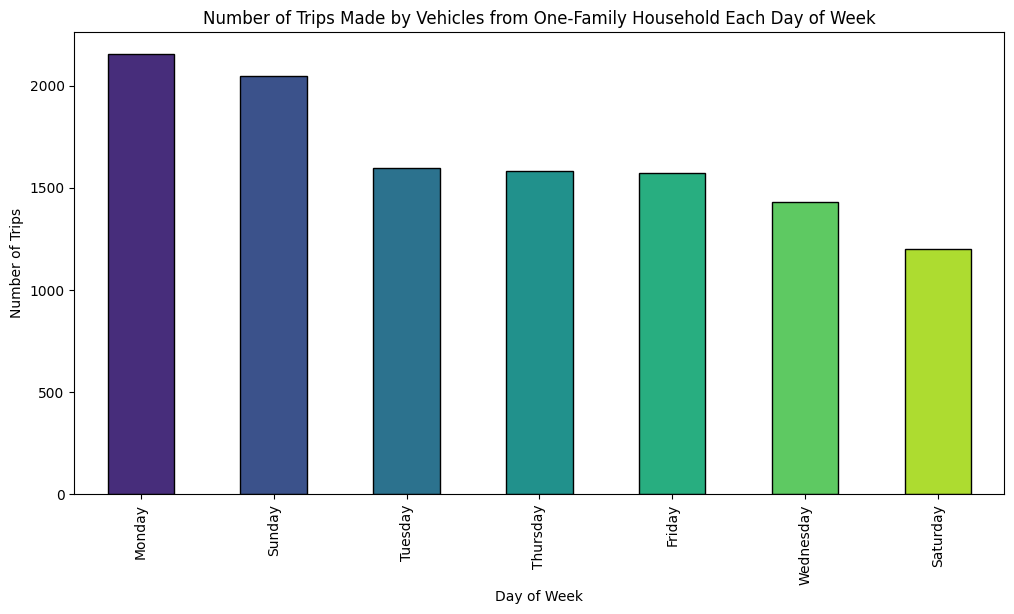

In [5]:
#bar chart
plt.figure(figsize = (12,6))
day_counts.plot(kind = 'bar', color = sns.color_palette('viridis', len(day_counts)), edgecolor = 'black')

#formatting
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.title('Number of Trips Made by Vehicles from One-Family Household Each Day of Week')

In [6]:
NHTS_data["vehicle_age"].max()

np.int64(40)

Text(0.5, 1.0, 'Age of Vehicles Belonging to One-Family Detached Households')

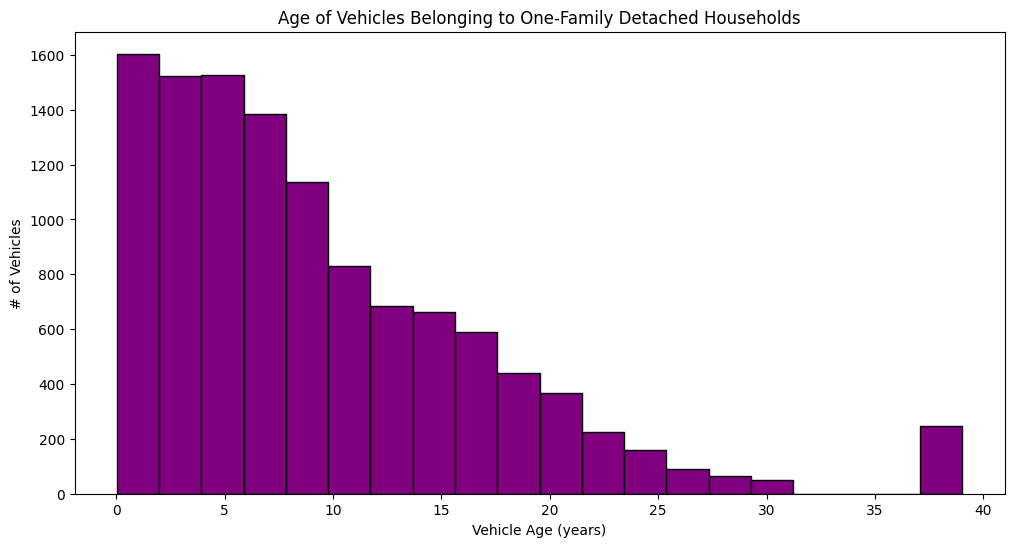

In [7]:
#histogram
plt.figure(figsize = (12,6))

plt.hist(NHTS_data[NHTS_data['home_type'] == 'One-family detached']['vehicle_age'], bins = 20, edgecolor = 'black', color = 'purple', align = 'left')

plt.xlabel('Vehicle Age (years)')
plt.ylabel('# of Vehicles')
plt.title('Age of Vehicles Belonging to One-Family Detached Households')


<Figure size 2000x1200 with 0 Axes>

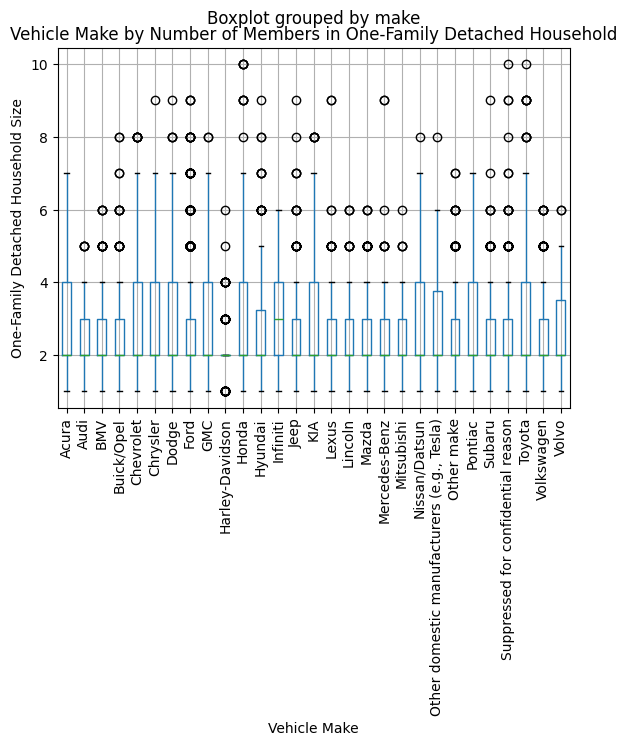

In [8]:
#boxplot
plt.figure(figsize = (20,12))
NHTS_onefam.boxplot(column = 'household_size', by = 'make', orientation = 'vertical',grid= True)

plt.xlabel('Vehicle Make')
plt.ylabel('One-Family Detached Household Size')
plt.title('Vehicle Make by Number of Members in One-Family Detached Household')
plt.xticks(rotation = 90)
plt.show()

In [9]:
#ngsim time graphs
trajectory_number = 4
data_subset = NGSIM_data[NGSIM_data['trajectory_number'] == trajectory_number]
gap = data_subset['leader_position(m)'].values - data_subset['follower_position(m)'].values


<Axes: xlabel='Time'>

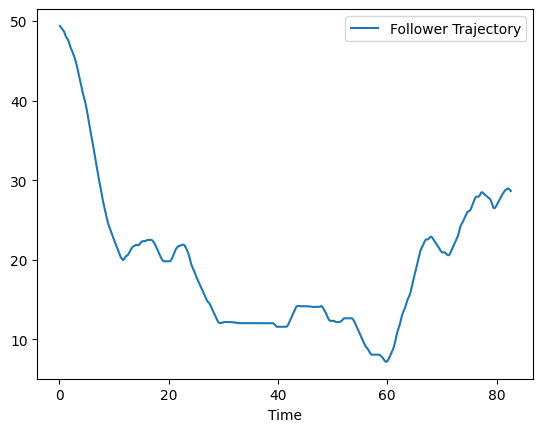

In [10]:
#follower acceleration and gap by time

sns.lineplot(x = data_subset['Time'], y = gap, label = 'Follower Trajectory')


<function matplotlib.pyplot.show(close=None, block=None)>

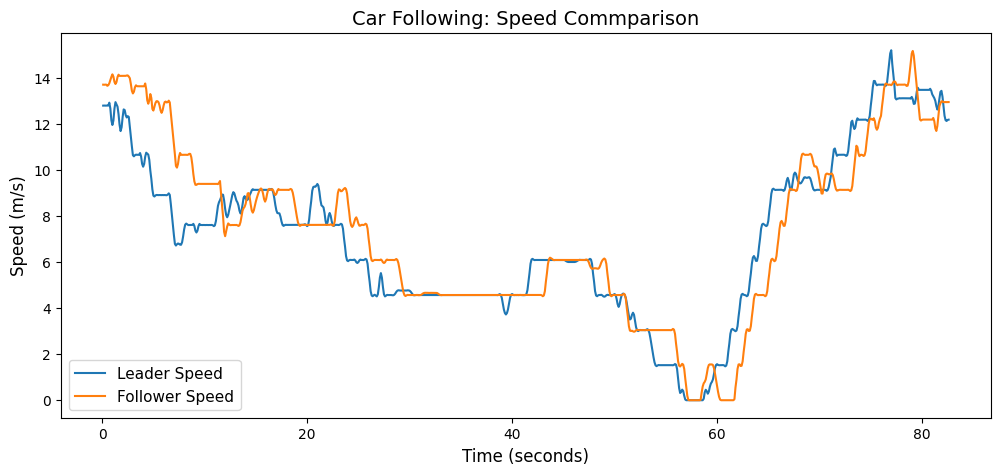

In [11]:
# Now replicate the same but visualizing speed

trajectory_number = 4 # vehicle pair x





# Plot the position of both vehicles over 
plt.figure(figsize = (12,5))
sns.lineplot(x = data_subset['Time'], y = data_subset['leader_speed(m/s)'], label = 'Leader Speed')
sns.lineplot(x = data_subset['Time'], y = data_subset['follower_speed(m/s)'], label = 'Follower Speed')


plt.xlabel('Time (seconds)', fontsize = 12)
plt.ylabel('Speed (m/s)', fontsize = 12)
plt.title('Car Following: Speed Commparison', fontsize = 14)

plt.legend(fontsize = 11)
plt.show

In [13]:

 # Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    
    
    
    # Make sure s_star is not negative
    s_star = max(s_star, s0)
    
    # Step 2: Calculate the acceleration using the IDM equation
    acceleration = a * (1 - (v/v0)**delta - (s_star/s)**2)
    
    
    
    return acceleration

In [14]:
# Load the NGSIM data to get the leader vehicle trajectory

ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair

trajectory_number = 4
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop= True)
# Extract the leader's position and speed over time

time_data = data_subset['Time'].values

leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values
# Identifying the time step in our data

dt = 0.1

In [16]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start



# Start at the real follower's initial state
sim_position[0] = data_subset['follower_position(m)'].values[0]        #this makes the starting value [0] same as the follower vehicle position
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]          #this makes the starting value [0] same as the follower vehicle speed



# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step

    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]
    
    # Step 3: Use the IDM function to calculate acceleration

    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta )
    
    # Step 4 & 5: Update speed and position for the next time step

    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt,0)
    sim_position[i+1] = sim_position[i]  + sim_speed[i] * dt

print("Simulation complete!")


Simulation complete!


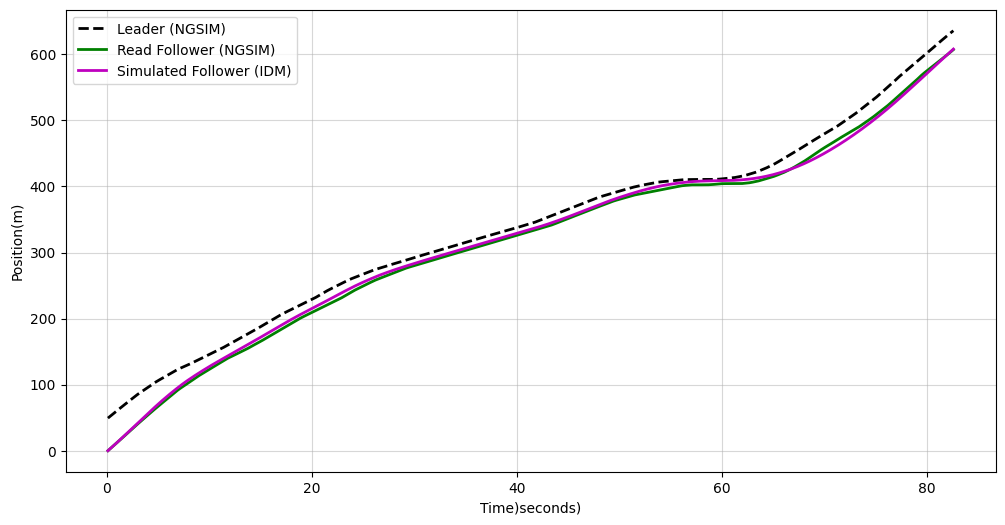

In [17]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, 'g-', linewidth = 2, label = 'Read Follower (NGSIM)')
plt.plot(time_data, sim_position, 'm-', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time)seconds)')
plt.ylabel('Position(m)')
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()